c:\Users\babie\OneDrive\바탕 화면\임시 ms 폴더\ch05
c:\Users\babie\OneDrive\바탕 화면\임시 ms 폴더
===========iteration:0===========
SGD:2.339634240946344
Momentum:2.482726356194628
AdaGrad:2.2942985565523153
Adam:2.1638503801287543
===========iteration:100===========
SGD:1.3667950860756095
Momentum:0.4387249781906374
AdaGrad:0.1320742137839434
Adam:0.25801374592295995
===========iteration:200===========
SGD:0.6868696279502229
Momentum:0.22889936436485658
AdaGrad:0.0818873115391955
Adam:0.12951298380019682
===========iteration:300===========
SGD:0.6127037020051593
Momentum:0.286475912257962
AdaGrad:0.11986243106208196
Adam:0.1534599330639846
===========iteration:400===========
SGD:0.34752011861133636
Momentum:0.11096926532500745
AdaGrad:0.05686929720225545
Adam:0.09517563985540994
===========iteration:500===========
SGD:0.32196397133131555
Momentum:0.11119115299094912
AdaGrad:0.0243283784459701
Adam:0.04590639188578885
===========iteration:600===========
SGD:0.35713283046411926
Momentum:0.184924286317

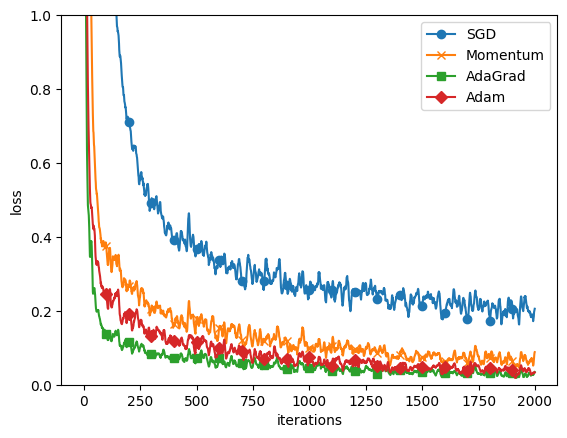

In [1]:
import os, sys
print(os.getcwd())
current_dir = os.path.dirname(os.getcwd())
print(current_dir)
os.chdir(current_dir)

import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.util import smooth_curve
from common.multi_layer_net import MultiLayerNet
from common.optimizer import *


# 0. MNIST 데이터 읽기==========
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)
train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000


# 1. 실험용 설정==========
optimizers = {}
optimizers['SGD'] = SGD()
optimizers['Momentum'] = Momentum()
optimizers['AdaGrad'] = AdaGrad()
optimizers['Adam'] = Adam()

networks = {}
train_loss = {}
for key in optimizers.keys():
    networks[key] = MultiLayerNet(
        input_size = 784, hidden_size_list=[100, 100, 100, 100],
        output_size=10
    )
    train_loss[key] = []    


# 2. 훈련 시작==========
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    for key in optimizers.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizers[key].update(networks[key].params, grads) 
        
        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)
    if i % 100 == 0:
        print( "===========" + "iteration:" + str(i) + "===========")
        for key in optimizers.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key+":"+str(loss))

# 3. 그래프 그리기==========
markers = {"SGD": "o", "Momentum": "x", "AdaGrad": "s", "Adam": "D"}
x = np.arange(max_iterations)
for key in optimizers.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 1)
plt.legend()
plt.show()
